# Практическая работа 1: поиск частых наборов


## 1. Задание

1. Найти частые наборы объектов в выбранном наборе данных с помощью алгоритмов Apriori, FP-Growth, ECLAT.
2. Варьировать порог поддержки: **1%, 3%, 5%, 10%, 15%, 20%**.
3. Проверить идентичность результатов разных алгоритмов.
4. Подготовить список частых наборов (не более 7 объектов) и дать содержательный анализ.
5. Построить визуализации:
   - быстродействие алгоритмов при изменении поддержки;
   - общее количество частых наборов;
   - максимальная длина частого набора;
   - распределение количества наборов по длинам.


In [105]:
from __future__ import annotations

import csv
from collections import Counter
from collections.abc import Sequence
from pathlib import Path
from statistics import mean, median
from time import perf_counter
from typing import Literal

import fim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (10, 6)


In [106]:
DATA_PATH = Path("baskets.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Файл baskets.csv не найден. Запустите ноутбук из каталога практики.")


## 2. Обзор данных

In [107]:
def load_transactions(path: Path) -> list[list[str]]:
    """Загружает транзакции из CSV-файла.

    Каждая строка файла интерпретируется как одна транзакция,
    элементы очищаются от пробелов и дедуплицируются внутри транзакции.

    :param path: Путь до CSV-файла с корзинами покупок.
    :return: Список транзакций, где транзакция — список товаров.
    """
    transactions: list[list[str]] = []
    with path.open(encoding="utf-8") as file:
        reader = csv.reader(file)
        for row in reader:
            items = sorted({value.strip() for value in row if value and value.strip()})
            if items:
                transactions.append(items)
    return transactions


In [108]:
transactions = load_transactions(DATA_PATH)
n_transactions = len(transactions)
print(f"Транзакций: {n_transactions}")

Транзакций: 7501


In [109]:
def build_dataset_overview(transactions: Sequence[Sequence[str]]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Формирует сводную статистику, топ-15 товаров и распределение размеров корзин.

    :param transactions: Коллекция транзакций.
    :return: Кортеж из трех DataFrame:
        1) общая статистика датасета;
        2) топ-15 товаров по частоте и поддержке;
        3) распределение корзин по их размеру.
    """
    basket_sizes = pd.Series([len(transaction) for transaction in transactions], name="Размер корзины")
    item_counter = Counter(item for transaction in transactions for item in transaction)

    summary_frame = pd.DataFrame(
        {
            "Показатель": [
                "Количество транзакций",
                "Количество уникальных товаров",
                "Средний размер корзины",
                "Минимальный размер корзины",
                "Максимальный размер корзины",
            ],
            "Значение": [
                len(transactions),
                len(item_counter),
                round(float(basket_sizes.mean()), 3),
                int(basket_sizes.min()),
                int(basket_sizes.max()),
            ],
        }
    )

    top_items_frame = pd.DataFrame(item_counter.most_common(15), columns=["Товар", "Количество"])
    top_items_frame["Поддержка"] = (top_items_frame["Количество"] / len(transactions)).round(4)

    basket_size_distribution = (
        basket_sizes.value_counts()
        .sort_index()
        .rename_axis("Размер корзины")
        .reset_index(name="Количество корзин")
    )

    return summary_frame, top_items_frame, basket_size_distribution


In [110]:
def plot_top_items_support(top_items_frame: pd.DataFrame) -> None:
    """Строит горизонтальную диаграмму поддержки для топ-15 товаров.

    :param top_items_frame: Таблица с колонками "Товар" и "Поддержка".
    :return: None.
    """
    plot_frame = top_items_frame.sort_values("Поддержка", ascending=True)
    plt.figure(figsize=(10, 6), dpi=120)
    plt.barh(plot_frame["Товар"], plot_frame["Поддержка"] * 100, color="#4c78a8")
    plt.title("Топ-15 товаров по поддержке")
    plt.xlabel("Поддержка, %")
    plt.ylabel("Товар")
    plt.tight_layout()
    plt.show()


In [111]:
def plot_basket_size_distribution(basket_size_df: pd.DataFrame) -> None:
    """Строит распределение количества корзин по числу товаров в них.

    :param basket_size_df: Таблица с колонками "Размер корзины" и "Количество корзин".
    :return: None.
    """
    plt.figure(figsize=(10, 6), dpi=120)
    plt.bar(
        basket_size_df["Размер корзины"],
        basket_size_df["Количество корзин"],
        color="#72b7b2",
    )
    plt.title("Распределение размеров корзин")
    plt.xlabel("Размер корзины")
    plt.ylabel("Количество")
    plt.yscale("log")
    plt.xticks(basket_size_df["Размер корзины"])
    plt.tight_layout()
    plt.show()


,Показатель,Значение
0,Количество транзакций,7501.000
1,Количество уникальных товаров,115.000
2,Средний размер корзины,3.909
3,Минимальный размер корзины,1.000
4,Максимальный размер корзины,20.000


,Товар,Количество,Поддержка
0,минеральная вода,1788,0.2384
1,макароны,1410,0.1880
2,яйца,1348,0.1797
3,картофель-фри,1282,0.1709
4,шоколад,1229,0.1638
5,зеленый чай,991,0.1321
6,молоко,972,0.1296
7,говяжий фарш,737,0.0983
8,замороженные овощи,715,0.0953
9,блинчики,713,0.0951


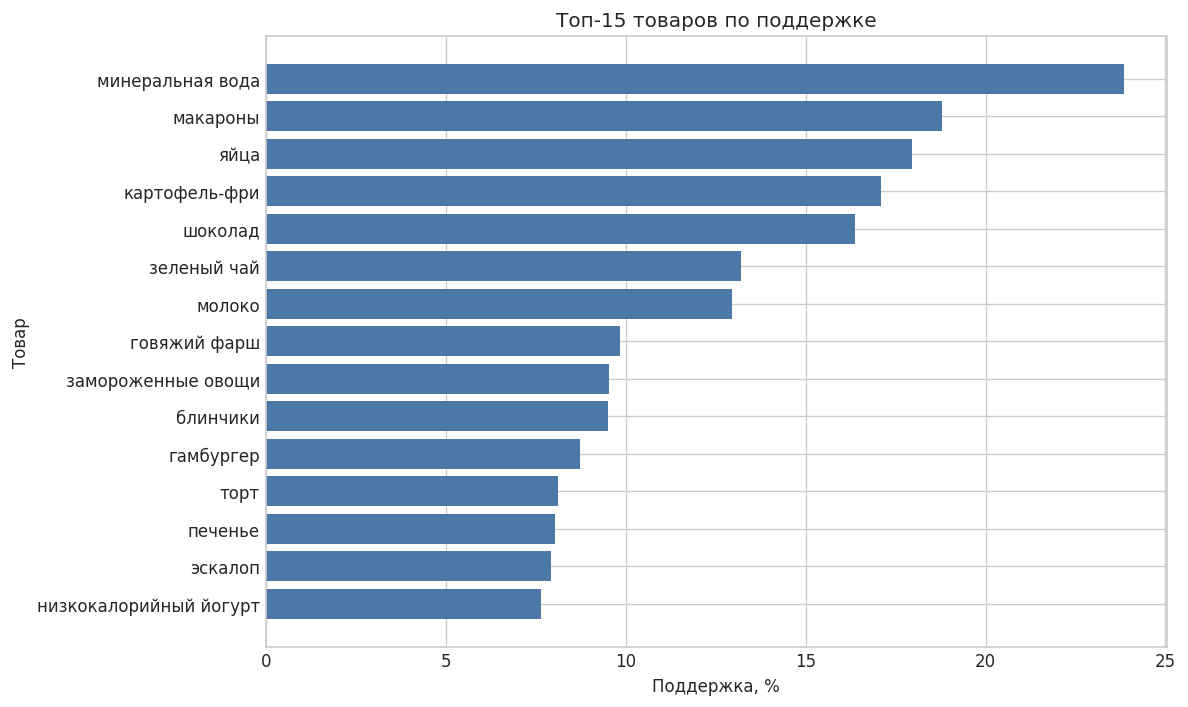

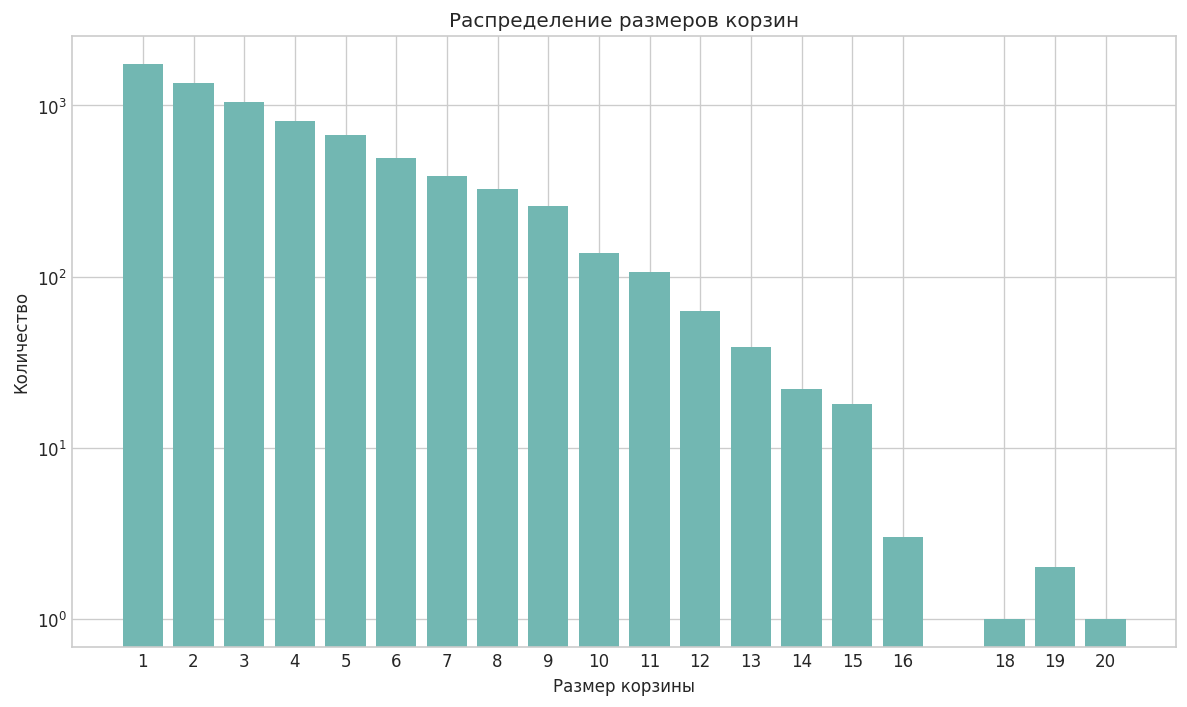

In [112]:
summary_df, item_freq_df, basket_size_df = build_dataset_overview(transactions)
display(summary_df)
display(item_freq_df)
plot_top_items_support(item_freq_df)
plot_basket_size_distribution(basket_size_df)


## 3. Реализация

Используются функции:
- `fim.apriori`
- `fim.fpgrowth`
- `fim.eclat`

Ограничение по длине набора устанавливается параметром `zmax=7`.


In [113]:
AlgorithmName = Literal["Apriori", "FP-Growth", "ECLAT"]
Itemset = frozenset[str]
ItemsetSupportMap = dict[Itemset, int]
ExperimentResults = dict[int, dict[AlgorithmName, ItemsetSupportMap]]
SortMethod = Literal["support", "lex"]


In [114]:
def run_fim_algorithm(
    algorithm_name: AlgorithmName,
    transactions: Sequence[Sequence[str]],
    min_support_percent: int,
    max_len: int = 7,
) -> ItemsetSupportMap:
    """Запускает выбранный алгоритм из pyfim.

    :param algorithm_name: Название алгоритма (`Apriori`, `FP-Growth`, `ECLAT`).
    :param transactions: Транзакции для майнинга.
    :param min_support_percent: Порог поддержки в процентах.
    :param max_len: Максимальная длина набора.
    :return: Словарь {частый набор: абсолютная поддержка}.
    """
    func_map = {
        "Apriori": fim.apriori,
        "FP-Growth": fim.fpgrowth,
        "ECLAT": fim.eclat,
    }
    if algorithm_name not in func_map:
        raise ValueError(f"Неизвестный алгоритм: {algorithm_name}")

    patterns = func_map[algorithm_name](
        transactions,
        target="s",
        supp=min_support_percent,
        zmin=1,
        zmax=max_len,
        report="a",
    )
    return {frozenset(items): int(support) for items, support in patterns}


In [115]:
def itemset_to_text(itemset: Itemset) -> str:
    """Преобразует частый набор в строку для табличного отображения.

    :param itemset: Набор товаров.
    :return: Строка товаров, отсортированных и разделенных запятой.
    """
    return ", ".join(sorted(itemset))


In [116]:
def sort_itemsets_frame(frame: pd.DataFrame, sort_method: SortMethod = "support") -> pd.DataFrame:
    """Сортирует таблицу частых наборов по выбранному методу.

    :param frame: Таблица с колонками `Набор`, `Поддержка`, `Поддержка (count)`, `Длина`.
    :param sort_method: `support` (по убыванию поддержки) или `lex` (лексикографически).
    :return: Отсортированная таблица.
    """
    if frame.empty:
        return frame

    if sort_method == "support":
        return frame.sort_values(
            by=["Длина", "Поддержка (count)", "Набор"],
            ascending=[True, False, True],
        ).reset_index(drop=True)

    if sort_method == "lex":
        return frame.sort_values(by=["Длина", "Набор"], ascending=[True, True]).reset_index(drop=True)

    raise ValueError("sort_method должен быть 'support' или 'lex'")


In [117]:
def itemsets_to_frame(
    itemsets: ItemsetSupportMap,
    total_transactions: int,
    sort_method: SortMethod = "support",
) -> pd.DataFrame:
    """Преобразует словарь частых наборов в DataFrame.

    :param itemsets: Словарь {набор: абсолютная поддержка}.
    :param total_transactions: Общее число транзакций в датасете.
    :param sort_method: Режим сортировки (`support` или `lex`).
    :return: Таблица частых наборов.
    """
    rows = [
        {
            "Набор": itemset_to_text(itemset),
            "Длина": len(itemset),
            "Поддержка (count)": support,
            "Поддержка": support / total_transactions,
        }
        for itemset, support in itemsets.items()
    ]
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame

    frame = sort_itemsets_frame(frame, sort_method=sort_method)
    frame["Поддержка"] = frame["Поддержка"].round(4)
    return frame


In [118]:
def run_experiments(
    transactions: Sequence[Sequence[str]],
    support_levels: Sequence[int],
    algorithms: Sequence[AlgorithmName],
    n_repeats: int,
    max_itemset_len: int,
) -> tuple[pd.DataFrame, ExperimentResults]:
    """Проводит серию экспериментов по всем порогам и алгоритмам.

    :param transactions: Коллекция транзакций исходного датасета.
    :param support_levels: Набор порогов поддержки в процентах.
    :param algorithms: Список алгоритмов для запуска.
    :param n_repeats: Число повторов для оценки времени выполнения.
    :param max_itemset_len: Максимальная длина частого набора.
    :return:
        - benchmark_df: таблица со временем и количеством найденных наборов;
        - results_by_support: вложенный словарь результатов по порогу и алгоритму.
    """
    benchmark_rows: list[dict[str, float | int | str]] = []
    results_by_support: ExperimentResults = {}

    for support in support_levels:
        results_by_support[support] = {}

        for algorithm in algorithms:
            timings: list[float] = []
            result: ItemsetSupportMap | None = None

            for _ in range(n_repeats):
                start = perf_counter()
                result = run_fim_algorithm(algorithm, transactions, support, max_itemset_len)
                timings.append(perf_counter() - start)

            assert result is not None
            results_by_support[support][algorithm] = result
            benchmark_rows.append(
                {
                    "Поддержка (%)": support,
                    "Алгоритм": algorithm,
                    "Медианное время (мс)": median(timings) * 1000,
                    "Среднее время (мс)": mean(timings) * 1000,
                    "Количество частых наборов": len(result),
                }
            )

    benchmark_df = pd.DataFrame(benchmark_rows).sort_values(["Поддержка (%)", "Алгоритм"])
    benchmark_df["Медианное время (мс)"] = benchmark_df["Медианное время (мс)"].round(4)
    benchmark_df["Среднее время (мс)"] = benchmark_df["Среднее время (мс)"].round(4)

    return benchmark_df, results_by_support


In [119]:
def build_identity_table(results_by_support: ExperimentResults, support_levels: Sequence[int]) -> pd.DataFrame:
    """Формирует таблицу проверки идентичности результатов алгоритмов.

    :param results_by_support: Результаты экспериментов по порогам и алгоритмам.
    :param support_levels: Набор порогов поддержки в процентах.
    :return: Таблица попарного сравнения результатов алгоритмов для каждого порога.
    """
    rows = []
    for support in support_levels:
        apriori_res = results_by_support[support]["Apriori"]
        fpgrowth_res = results_by_support[support]["FP-Growth"]
        eclat_res = results_by_support[support]["ECLAT"]

        rows.append(
            {
                "Поддержка (%)": support,
                "Apriori = FP-Growth": apriori_res == fpgrowth_res,
                "Apriori = ECLAT": apriori_res == eclat_res,
                "FP-Growth = ECLAT": fpgrowth_res == eclat_res,
                "Количество наборов": len(apriori_res),
            }
        )
    return pd.DataFrame(rows)


In [120]:
def build_length_statistics(
    results_by_support: ExperimentResults,
    support_levels: Sequence[int],
    reference_algorithm: AlgorithmName = "Apriori",
) -> tuple[pd.DataFrame, dict[int, Counter[int]], pd.DataFrame]:
    """Готовит сводку по длинам наборов и матрицу распределения.

    :param results_by_support: Результаты экспериментов по порогам и алгоритмам.
    :param support_levels: Набор порогов поддержки в процентах.
    :param reference_algorithm: Алгоритм, по которому строится статистика длин.
    :return:
        - summary_df: число наборов и максимальная длина для каждого порога;
        - length_distribution: словарь {support: Counter({length: count})};
        - length_matrix: табличная матрица "длина x порог".
    """
    summary_rows: list[dict[str, int]] = []
    length_distribution: dict[int, Counter[int]] = {}

    for support in support_levels:
        result = results_by_support[support][reference_algorithm]
        lengths = [len(itemset) for itemset in result.keys()]
        length_distribution[support] = Counter(lengths)

        summary_rows.append(
            {
                "Поддержка (%)": support,
                "Количество частых наборов": len(result),
                "Максимальная длина": max(lengths) if lengths else 0,
            }
        )

    summary_df = pd.DataFrame(summary_rows)
    max_len_observed = max(max(counter.keys()) for counter in length_distribution.values())
    all_lengths = list(range(1, max_len_observed + 1))

    length_matrix = pd.DataFrame(index=all_lengths)
    for support in support_levels:
        length_matrix[f"{support}%"] = [length_distribution[support].get(length, 0) for length in all_lengths]

    return summary_df, length_distribution, length_matrix


In [121]:
def plot_runtime(benchmark_df: pd.DataFrame, algorithms: Sequence[AlgorithmName]) -> None:
    """Строит график сравнения быстродействия алгоритмов.

    :param benchmark_df: Таблица с результатами бенчмарка.
    :param algorithms: Список алгоритмов для отображения на графике.
    :return: None.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for algo in algorithms:
        subset = benchmark_df[benchmark_df["Алгоритм"] == algo]
        ax.plot(
            subset["Поддержка (%)"],
            subset["Медианное время (мс)"],
            marker="o",
            linewidth=2,
            label=algo,
        )

    ax.set_title("Сравнение быстродействия алгоритмов")
    ax.set_xlabel("Порог поддержки, %")
    ax.set_ylabel("Медианное время, мс")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()


In [122]:
def plot_summary_metrics(summary_df: pd.DataFrame) -> None:
    """Строит 2 графика: общее количество наборов и максимальная длина.

    :param summary_df: Сводная таблица по количеству и максимальной длине наборов.
    :return: None.
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

    axes[0].plot(
        summary_df["Поддержка (%)"],
        summary_df["Количество частых наборов"],
        marker="o",
        linewidth=2,
        color="#1f77b4",
    )
    axes[0].set_title("Общее количество частых наборов")
    axes[0].set_ylabel("Количество")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        summary_df["Поддержка (%)"],
        summary_df["Максимальная длина"],
        marker="o",
        linewidth=2,
        color="#d62728",
    )
    axes[1].set_title("Максимальная длина частого набора")
    axes[1].set_xlabel("Порог поддержки, %")
    axes[1].set_ylabel("Длина")
    axes[1].set_ylim(0, int(summary_df["Максимальная длина"].max()) + 1)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [123]:
def plot_length_heatmap(length_matrix: pd.DataFrame) -> None:
    """Строит тепловую карту распределения длин наборов.

    :param length_matrix: Матрица распределения «длина набора x порог поддержки».
    :return: None.
    """
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(length_matrix.values, cmap="YlGnBu", aspect="auto")
    ax.set_xticks(np.arange(len(length_matrix.columns)))
    ax.set_xticklabels(length_matrix.columns)
    ax.set_yticks(np.arange(len(length_matrix.index)))
    ax.set_yticklabels(length_matrix.index)
    ax.set_xlabel("Порог поддержки")
    ax.set_ylabel("Длина набора")
    ax.set_title("Распределение количества частых наборов по длинам")

    for i in range(length_matrix.shape[0]):
        for j in range(length_matrix.shape[1]):
            ax.text(j, i, int(length_matrix.iloc[i, j]), ha="center", va="center", fontsize=9, color="black")

    fig.colorbar(im, ax=ax, label="Количество наборов")
    plt.tight_layout()
    plt.show()


In [124]:
def plot_length_stacked_bar(length_matrix: pd.DataFrame) -> None:
    """Строит stacked bar диаграмму по длинам частых наборов.

    :param length_matrix: Матрица распределения «длина набора x порог поддержки».
    :return: None.
    """
    thresholds = list(length_matrix.columns)
    bottom = np.zeros(len(thresholds), dtype=int)

    fig, ax = plt.subplots(figsize=(10, 6))
    for length in length_matrix.index:
        values = length_matrix.loc[length].to_numpy(dtype=int)
        ax.bar(thresholds, values, bottom=bottom, label=f"Длина {length}")
        bottom += values

    ax.set_title("Количество частых наборов по длинам")
    ax.set_xlabel("Порог поддержки")
    ax.set_ylabel("Количество частых наборов")
    ax.legend(title="Длина набора")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Эксперимент: сравнение алгоритмов

In [125]:
SUPPORT_LEVELS = [1, 3, 5, 10, 15, 20]  # проценты
ALGORITHMS: list[AlgorithmName] = ["Apriori", "FP-Growth", "ECLAT"]
N_REPEATS = 20
MAX_ITEMSET_LEN = 7
SORT_METHOD: SortMethod = "support"

benchmark_df, results_by_support = run_experiments(
    transactions=transactions,
    support_levels=SUPPORT_LEVELS,
    algorithms=ALGORITHMS,
    n_repeats=N_REPEATS,
    max_itemset_len=MAX_ITEMSET_LEN,
)

display(benchmark_df)
print(f"Режим сортировки для таблиц частых наборов: {SORT_METHOD}")

,Поддержка (%),Алгоритм,Медианное время (мс),Среднее время (мс),Количество частых наборов
0,1,Apriori,2.4698,3.0304,261
2,1,ECLAT,2.1649,2.2817,261
1,1,FP-Growth,1.9406,1.9233,261
3,3,Apriori,1.6580,1.6917,55
5,3,ECLAT,1.5562,1.5872,55
4,3,FP-Growth,1.5452,1.6250,55
6,5,Apriori,1.4248,1.4402,28
8,5,ECLAT,1.4338,1.4773,28
7,5,FP-Growth,1.4012,1.4871,28
9,10,Apriori,1.0591,1.1081,7


Режим сортировки для таблиц частых наборов: support


In [126]:
identity_df = build_identity_table(results_by_support, SUPPORT_LEVELS)
display(identity_df)

assert identity_df[["Apriori = FP-Growth", "Apriori = ECLAT", "FP-Growth = ECLAT"]].to_numpy().all(), (
    "Результаты алгоритмов не совпадают"
)
print("Идентичность результатов подтверждена для всех порогов поддержки.")

,Поддержка (%),Apriori = FP-Growth,Apriori = ECLAT,FP-Growth = ECLAT,Количество наборов
0,1,True,True,True,261
1,3,True,True,True,55
2,5,True,True,True,28
3,10,True,True,True,7
4,15,True,True,True,5
5,20,True,True,True,1


Идентичность результатов подтверждена для всех порогов поддержки.


## 5. Визуализация результатов

### 5.1 Быстродействие алгоритмов

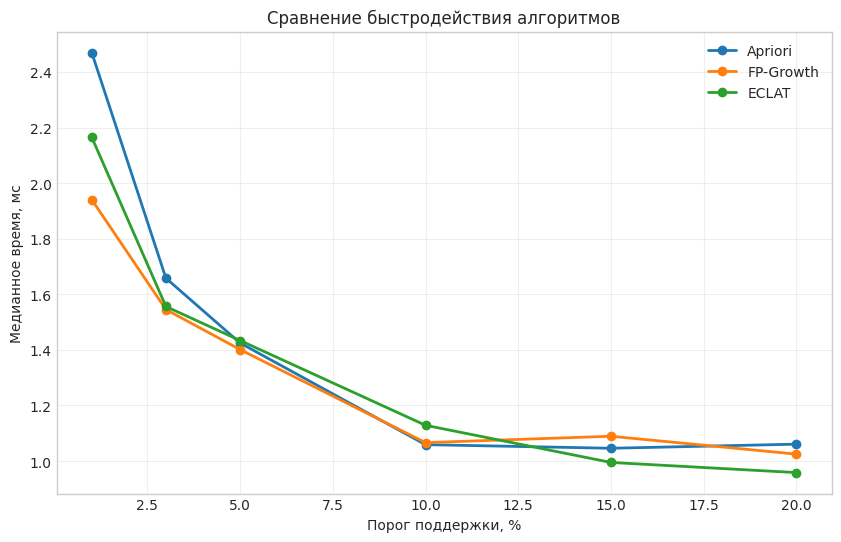

In [127]:
plot_runtime(benchmark_df, ALGORITHMS)

### 5.2 Общее количество частых наборов и максимальная длина

,Поддержка (%),Количество частых наборов,Максимальная длина
0,1,261,3
1,3,55,2
2,5,28,2
3,10,7,1
4,15,5,1
5,20,1,1


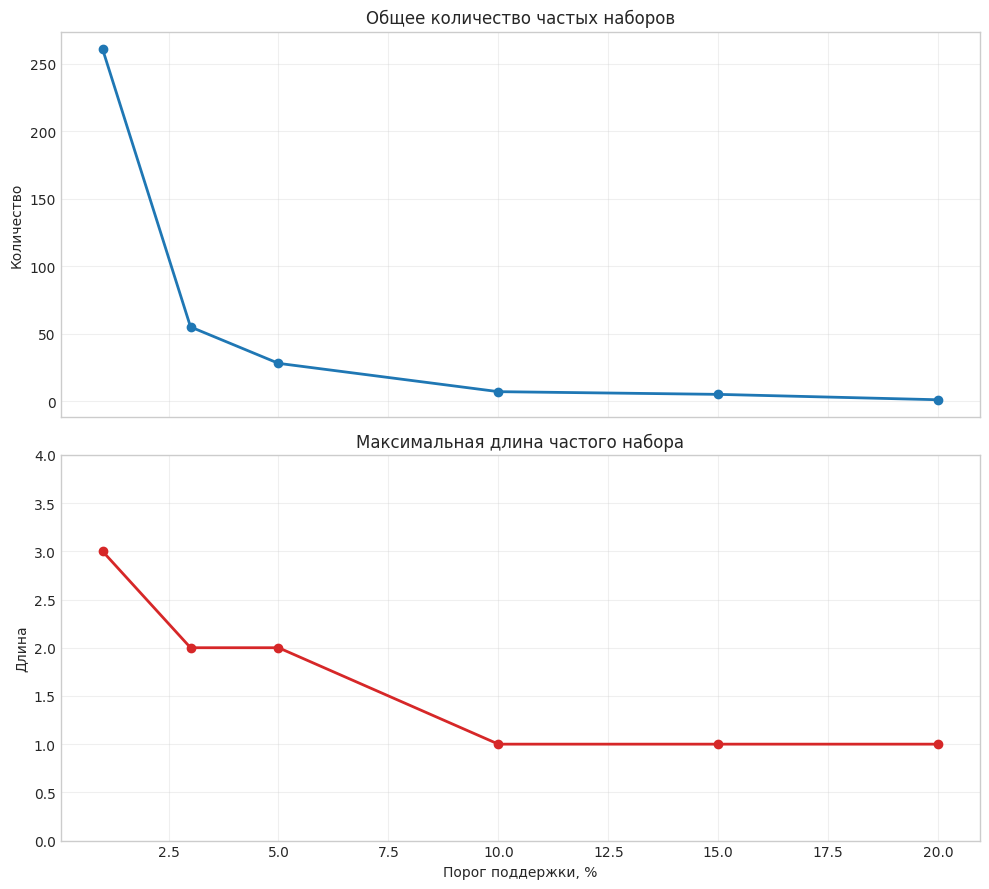

In [128]:
summary_df, length_distribution, length_matrix = build_length_statistics(
    results_by_support=results_by_support,
    support_levels=SUPPORT_LEVELS,
    reference_algorithm="Apriori",
)

display(summary_df)
plot_summary_metrics(summary_df)

### 5.3 Количество частых наборов различной длины

Ниже показаны две формы визуализации распределения по длинам:
- heatmap (матрица длина × порог поддержки);
- stacked bar (накопленные столбцы по длинам наборов).


,1%,3%,5%,10%,15%,20%
1,74,36,25,7,5,1
2,170,19,3,0,0,0
3,17,0,0,0,0,0


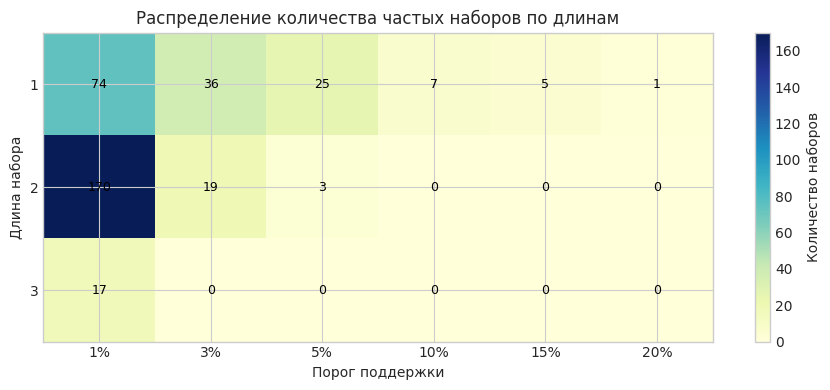

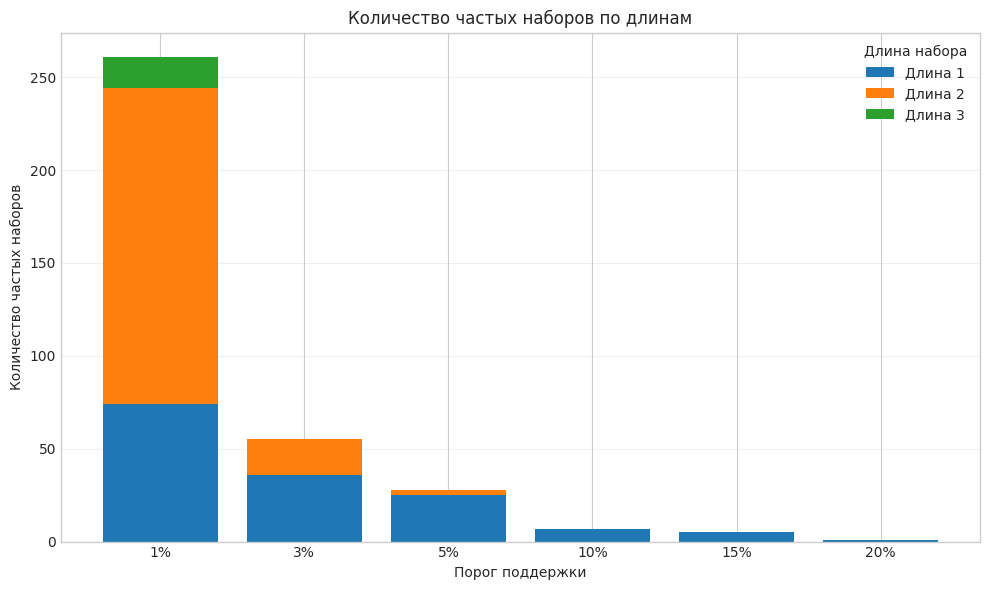

In [129]:
display(length_matrix)
plot_length_heatmap(length_matrix)
plot_length_stacked_bar(length_matrix)

## 6. Список частых наборов (не более 7 объектов)

Выведем наборы для минимального порога поддержки (1%)

In [130]:
report_support = 1
report_result = results_by_support[report_support]["Apriori"]
report_frame = itemsets_to_frame(
    itemsets=report_result,
    total_transactions=n_transactions,
    sort_method=SORT_METHOD,
)
report_frame = report_frame[report_frame["Длина"] <= 7]

# Показываем до 12 наборов на каждую длину.
report_sample = (
    report_frame
    .sort_values(["Длина", "Поддержка"], ascending=[False, False])
    .groupby("Длина", group_keys=False)
    .head(12)
    .reset_index(drop=True)
)

display(report_sample)
print(f"Всего частых наборов при поддержке 1%: {len(report_frame)}")

,Набор,Длина,Поддержка (count),Поддержка
0,"говяжий фарш, макароны, минеральная вода",3,129,0.0172
1,"макароны, минеральная вода, шоколад",3,123,0.0164
2,"макароны, минеральная вода, молоко",3,121,0.0161
3,"макароны, минеральная вода, яйца",3,114,0.0152
4,"минеральная вода, молоко, шоколад",3,105,0.0140
5,"минеральная вода, шоколад, яйца",3,101,0.0135
6,"минеральная вода, молоко, яйца",3,98,0.0131
7,"замороженные овощи, макароны, минеральная вода",3,92,0.0123
8,"блинчики, макароны, минеральная вода",3,88,0.0117
9,"макароны, молоко, шоколад",3,84,0.0112


Всего частых наборов при поддержке 1%: 261


## 7. Пояснения и интерпретация результатов

1. **Идентичность результатов подтверждена:** для всех порогов поддержки три алгоритма выдают одинаковые частые наборы.
2. **Рост поддержки уменьшает число наборов:**
   - 1%: 261 набор;
   - 3%: 55 наборов;
   - 5%: 28 наборов;
   - 10%: 7 наборов;
   - 15%: 5 наборов;
   - 20%: 1 набор.
3. **Максимальная длина частого набора** снижается с ростом поддержки: от 3 (при 1%) до 1 (при 10% и выше).
4. **Содержательный вывод:** наиболее устойчивые паттерны относятся к базовым товарам массового спроса; при порогах 10%, 15% и 20% остаются только одиночные товары, а пары встречаются лишь на более низких порогах.
5. **Сравнение скорости:** на данном датасете все три алгоритма работают очень быстро; в измерениях FP-Growth и ECLAT немного быстрее Apriori на большинстве порогов поддержки.
